In [137]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from numpy.polynomial.polynomial import Polynomial
from scipy.optimize import curve_fit

import scipy.stats as stats

In [138]:
# F_Data is a Matrix, each row is a time series
F_Data = np.load("F.npy")
t = np.arange(0,4097,1)
t_list = [ i for i in range(0,4097,1)]


In [ ]:
def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def DFAn(time_series, min_scale=4, max_scale=4096, num_scales=20, order=1):
    N = len(time_series)

    # Compute profile
    mean_x = np.mean(time_series)
    Y = np.cumsum(time_series - mean_x)

    # Define scales
    scales = np.logspace(np.log10(min_scale), np.log10(max_scale), num_scales, dtype=int)
    F = []

    # Loop over scales
    for s in scales:
        segments = N // s
        rms = []

        for i in range(segments):
            idx = slice(i * s, (i + 1) * s)
            segment = Y[idx]
            x = np.arange(len(segment))

            # Fit polynomial trend of the LOCAL TREND
            m,c = np.polyfit(x, segment, order)
            trend = (m * x) + c

            # Compute RMS OF LOCAL FLUCTUATIONS
            fluctuation = np.sqrt(np.mean((segment - trend) ** 2))
            rms.append(fluctuation)

        # Compute RMS MEAN
        F.append(np.sqrt(np.mean(np.array(rms)**2)))

    x_data = scales  # Scale (n) values
    y_data = F  # Root Mean Square F(n) values

    # Apply log10 transformation to x_data (since the plot is in log-log space)
    log_x_data = np.log10(x_data)

    # Fit the sigmoid function to the log-transformed x_data
    popt, _ = curve_fit(sigmoid, log_x_data, y_data, p0=[max(y_data), np.median(log_x_data), 1])

    # Generate fitted curve
    x_fit = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 100)
    y_fit = sigmoid(np.log10(x_fit), *popt)
    
    return scales, F, x_fit, y_fit, popt

def sigfit()

[946.16217189   3.62848751   2.25498149]
[np.float64(2.704732181173396), np.float64(4.351365693019075), np.float64(9.729534799965265), np.float64(16.197134817878748), np.float64(30.722289730348333), np.float64(48.653125924147595), np.float64(78.41291909142042), np.float64(137.5889557416098), np.float64(198.59624084887622)]


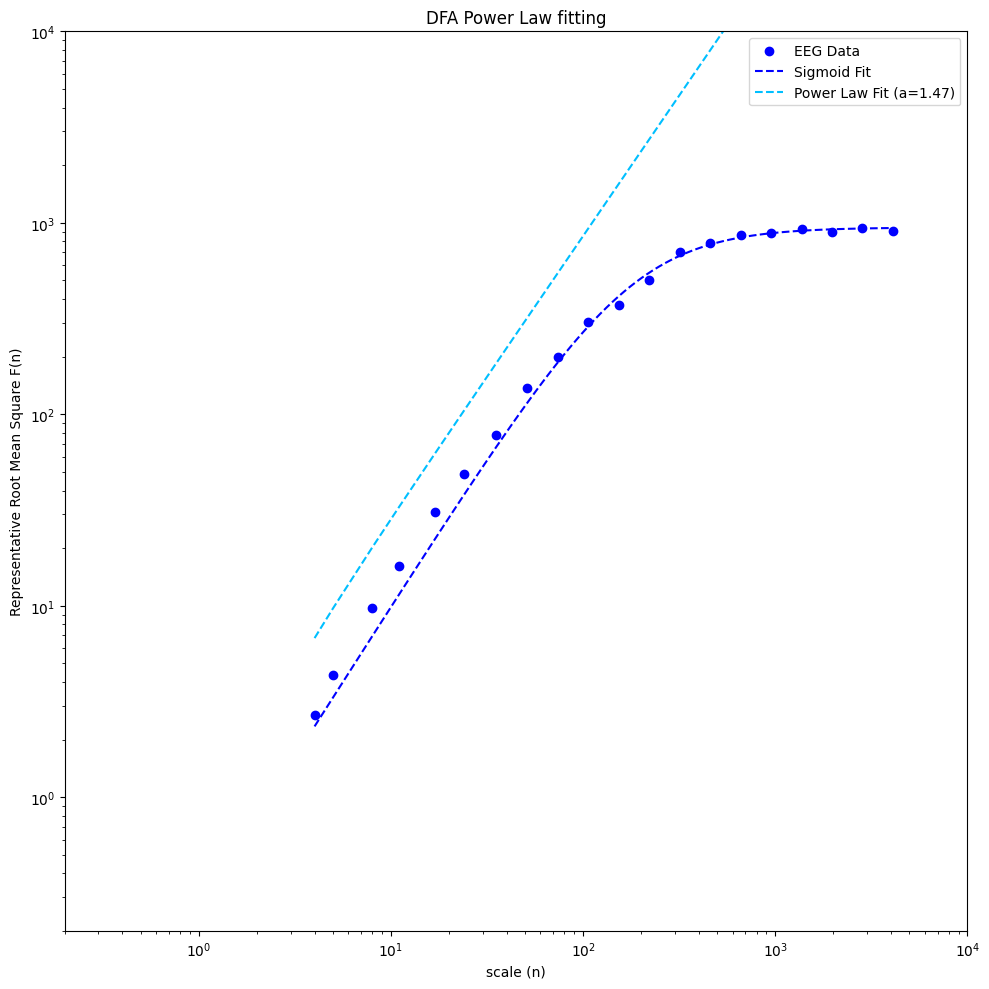

In [141]:
color = ['b','m','k']
names = ['EEG Data','brown noise','white noise']
fit_names = []
fig , axs = plt.subplots(figsize = (10,10))

for i in range(1):
    scales, F, x_fit, y_fit, popt = DFAn(dataset[i], min_scale=4, max_scale=4096, num_scales=20, order=1)

    axs.scatter(scales, F, label=names[i], color=color[i])
    axs.plot(x_fit, y_fit, '--', label="Sigmoid Fit", color=color[i])
    axs.set_xscale('log')
    axs.set_yscale('log')
    axs.set_xlabel('scale (n)')
    axs.set_ylabel("Representative Root Mean Square F(n)")
    axs.set_title(f'3 independent datasets')  # Fixed method
    plt.legend()

    print(popt)

# Example: Simulated power-law region (Replace this with your real data)
x = scales[scales < 100]  # Chosen from the power-law segment
y = F[:9]  # Follows y = x^a (e.g., a = 2)
print(y)

# Log transform
log_x = np.log(x)
log_y = np.log(y)

# Perform linear regression
slope, intercept, _, _, _ = stats.linregress(log_x, log_y)

plt.plot(scales, scales**slope + intercept, '--', color='deepskyblue' , label=f"Power Law Fit (a={slope:.2f})")
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel('scale (n)')
axs.set_ylabel("Representative Root Mean Square F(n)")
axs.set_title(f'DFA Power Law fitting')  # Fixed method
plt.legend()


plt.ylim(0.2, 10**4)
plt.xlim(0.2, 10**4)
plt.tight_layout()
plt.savefig('DFA Power Law.png', dpi=100)

